In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Quitar el límite de columnas máximas a mostrar
pd.set_option('display.max_columns', None)


In [ ]:
def cargar_datos_con_fuerza(ruta):
    """
    Forzar la lectura de datos ignorando errores de formato.
    """
    try:
        # 1. Probar lectura saltando posibles líneas vacías al inicio
        # 2. Usar engine='python' para mayor flexibilidad con separadores
        # 3. On_bad_lines='skip' para no frenar el proceso si una fila falla
        df = pd.read_csv(ruta, 
                         sep=';', 
                         encoding='latin-1', 
                         engine='python', 
                         on_bad_lines='skip', 
                         skip_blank_lines=True)

        if df.empty:
            print("⚠️ Advertencia: El DataFrame sigue vacío. Intentar cambiar el separador.")
            # Probar con coma si el punto y coma falla
            df = pd.read_csv(ruta, sep=',', encoding='latin-1')

        print(f"✅ Éxito: Se cargaron {df.shape[0]} filas y {df.shape[1]} columnas.")
        return df

    except Exception as e:
        print(f"❌ Error crítico: {e}")
        return None


In [7]:
df_lengua = cargar_datos_con_fuerza("2024 Base APRENDER - Censal - Secundaria 5-6 año - Agregada - Desempeños de Lengua(in).csv")
df_matematica = cargar_datos_con_fuerza("2024 Base APRENDER - Censal - Secundaria 5-6 año - Agregada - Desempeños de Matematica(in).csv")
df_solo = cargar_datos_con_fuerza("2024 Base APRENDER - Censal - Secundaria 5-6 año - Agregada - Solo CC(in).csv")
df_diccionario = cargar_datos_con_fuerza("2011 - 2024  - Diccionario bases aprender anonimizadas(2024 Estudiantes - APRENDER Sec).csv")

✅ Éxito: Se cargaron 1175 filas y 1035 columnas.
✅ Éxito: Se cargaron 1175 filas y 1035 columnas.
✅ Éxito: Se cargaron 1175 filas y 1031 columnas.
✅ Éxito: Se cargaron 1064 filas y 5 columnas.


In [8]:
df_diccionario

,Variable,#¡VALOR!,Etiqueta de variables,Etiqueta de variables.1,Unnamed: 4
0,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Ciudad Autónoma de Bu...,Código de Jurisdicción,Ciudad Autónoma de Buenos Aires
1,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Buenos Aires,Código de Jurisdicción,Buenos Aires
2,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Catamarca,Código de Jurisdicción,Catamarca
3,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Córdoba,Código de Jurisdicción,Córdoba
4,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Corrientes,Código de Jurisdicción,Corrientes
...,...,...,...,...,...
1059,Nivel_Ed_Persona_Resp_Primaria_completo,Nivel_Ed_Persona_Resp_,Máximo nivel educativo adulto responsable - Pr...,Máximo nivel educativo adulto responsable,Primaria completo
1060,Nivel_Ed_Persona_Resp_Secundaria_incompleto,Nivel_Ed_Persona_Resp_,Máximo nivel educativo adulto responsable - Se...,Máximo nivel educativo adulto responsable,Secundaria incompleto
1061,Nivel_Ed_Persona_Resp_Secundaria_completo,Nivel_Ed_Persona_Resp_,Máximo nivel educativo adulto responsable - Se...,Máximo nivel educativo adulto responsable,Secundaria completo
1062,Nivel_Ed_Persona_Resp_Terciario_universitario_...,Nivel_Ed_Persona_Resp_,Máximo nivel educativo adulto responsable - Te...,Máximo nivel educativo adulto responsable,Terciario/universitario/posgrado incompleto


In [9]:
# 1. Mover la fila 0 a los nombres de columna
df_diccionario.columns = df_diccionario.iloc[0]

# 2. Eliminar la fila duplicada y resetear el índice
df_diccionario = df_diccionario[1:].reset_index(drop=True)

# 3. Limpiar espacios en los nombres
df_diccionario.columns = df_diccionario.columns.astype(str).str.strip()

# 4. Quitar columnas vacías
df_diccionario = df_diccionario.loc[:, ~df_diccionario.columns.str.contains('^Unnamed', na=False)]

# Mostrar resultado
df_diccionario.head()


,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Ciudad Autónoma de Buenos Aires,Código de Jurisdicción,Ciudad Autónoma de Buenos Aires
0,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Buenos Aires,Código de Jurisdicción,Buenos Aires
1,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Catamarca,Código de Jurisdicción,Catamarca
2,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Córdoba,Código de Jurisdicción,Córdoba
3,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Corrientes,Código de Jurisdicción,Corrientes
4,jurisdiccion,#¡VALOR!,Código de Jurisdicción - Chaco,Código de Jurisdicción,Chaco


In [10]:
# Forzar el detalle de las 1035 columnas
df_matematica.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 1035 columns):
 #     Column                                                           Non-Null Count  Dtype 
---    ------                                                           --------------  ----- 
 0     jurisdiccion                                                     1175 non-null   object
 1     departamento                                                     1175 non-null   object
 2     sector                                                           1175 non-null   object
 3     ambito                                                           1175 non-null   object
 4     ap01_Blanco                                                      1175 non-null   object
 5     ap01_No_disponible                                               1175 non-null   object
 6     ap01_Multimarca                                                  1175 non-null   object
 7     ap01_Enero                   

In [11]:
df_lengua.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 1035 columns):
 #     Column                                                           Non-Null Count  Dtype 
---    ------                                                           --------------  ----- 
 0     jurisdiccion                                                     1175 non-null   object
 1     departamento                                                     1175 non-null   object
 2     sector                                                           1175 non-null   object
 3     ambito                                                           1175 non-null   object
 4     ap01_Blanco                                                      1175 non-null   object
 5     ap01_No_disponible                                               1175 non-null   object
 6     ap01_Multimarca                                                  1175 non-null   object
 7     ap01_Enero                   

In [12]:
# 1. Agregar la columna identificadora a los objetos existentes
df_matematica['materia'] = 'Matematica'
df_lengua['materia'] = 'Lengua'

# 2. Unir una debajo de otra (Apilar)
df_nacional = pd.concat([df_matematica, df_lengua], axis=0, ignore_index=True)

# 3. Limpiar nombres de columnas por seguridad
df_nacional.columns = df_nacional.columns.str.strip()

# Ver el resultado
print(f"Filas totales: {len(df_nacional)}")
print(f"Columnas totales: {len(df_nacional.columns)}")

Filas totales: 2350
Columnas totales: 1040


In [50]:
df_nacional

jurisdiccion departamento   sector  \
0                       Ciudad Autónoma de Buenos Aires     Comuna 1  Estatal   
1                       Ciudad Autónoma de Buenos Aires     Comuna 1  Privado   
2                       Ciudad Autónoma de Buenos Aires    Comuna 10  Estatal   
3                       Ciudad Autónoma de Buenos Aires    Comuna 10  Privado   
4                       Ciudad Autónoma de Buenos Aires    Comuna 11  Estatal   
...                                                 ...          ...      ...   
2345  Tierra del Fuego, Antártida e Islas del Atlánt...   RIO GRANDE  Estatal   
2346  Tierra del Fuego, Antártida e Islas del Atlánt...   RIO GRANDE  Privado   
2347  Tierra del Fuego, Antártida e Islas del Atlánt...      TOLHUIN  Estatal   
2348  Tierra del Fuego, Antártida e Islas del Atlánt...      USHUAIA  Estatal   
2349  Tierra del Fuego, Antártida e Islas del Atlánt...      USHUAIA  Privado   

      ambito ap01_Blanco ap01_No_disponible ap01_Multimarca   ap01_Enero  \
0     Urbano                                                 146,2063165   
1     Urbano                                                 138,6054147   
2     Urbano                                                  69,4946682   
3     Urbano                                                 105,5570206   
4     Urbano                                                  73,8012536   
...      ...         ...                ...             ...          ...   
2345  Urbano                                                  96,6226887   
2346  Urbano                                                  29,1242249   
2347  Urbano                                                  15,1383566   
2348  Urbano                                                  88,5691991   
2349  Urbano                                                  18,4857062   

     ap01_Febrero   ap01_Marzo   ap01_Abril    ap01_Mayo   ap01_Junio  \
0     154,3499187  155,7769437  141,8792408  172,4896781  154,5377838   
1     104,6391649  104,1424043   99,1057825   90,2106628   79,7474105   
2      93,2044307   78,7659049   94,0982826   94,5533627   63,8591688   
3       79,142254   90,8757785  102,9663564   98,8170558  101,2825025   
4      51,0019555   59,0418048   42,2514955   62,0385027   59,4057206   
...           ...          ...          ...          ...          ...   
2345   89,8733082   84,2242895    95,909784   74,3868355   90,8976696   
2346   32,2944839   22,2873299   27,8956453   30,5047283   30,4239413   
2347   12,1500952    8,6702739    4,4385785   11,8748218     1,525975   
2348   73,1652371   58,3403028   68,9933819   69,0003691   75,6964717   
2349    23,280306   21,6850174   21,7667413   23,4707909   15,4130196   

       ap01_Julio  ap01_Agosto ap01_Septiembre ap01_Octubre ap01_Noviembre  \
0     143,2492294  144,0149367     169,8708801  130,9898903    107,8696772   
1      88,4540419  104,5014821     109,8686072   92,4684744     95,4233772   
2      56,3994881   73,9461177      58,9838158   83,3375918     71,1772934   
3     107,6324967   107,420874     103,4868892  107,7433086    118,1864762   
4      64,2846166   54,3881817      54,0605194   69,3010199     68,4758592   
...           ...          ...             ...          ...            ...   
2345   71,2813476   75,7498321      83,8969587  109,0149817     66,9610575   
2346   38,9983641   29,7406613      30,6433845    25,610532     46,0220339   
2347   11,8889271    3,0070684       8,7104538                   3,6324192   
2348   55,8244734   72,8279884      61,3176219   91,4795284      82,545664   
2349    28,453528   23,6985026      29,1116662   22,1299425     27,1249068   

     ap01_Diciembre ap02_Blanco ap02_No_disponible ap02_Multimarca  \
0       139,0296202                                                  
1        121,524358                                                  
2       104,2514519                                                  
3         99,170697                                            

In [13]:
df_nacional.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2350 entries, 0 to 2349
Data columns (total 1040 columns):
 #     Column                                                           Non-Null Count  Dtype 
---    ------                                                           --------------  ----- 
 0     jurisdiccion                                                     2350 non-null   object
 1     departamento                                                     2350 non-null   object
 2     sector                                                           2350 non-null   object
 3     ambito                                                           2350 non-null   object
 4     ap01_Blanco                                                      2350 non-null   object
 5     ap01_No_disponible                                               2350 non-null   object
 6     ap01_Multimarca                                                  2350 non-null   object
 7     ap01_Enero                   

In [15]:
df_nacional.to_pickle('df_nacional.pkl')

In [36]:
# Mapeo de Títulos a Códigos (Podés seguir agregando aquí)
diccionario_variables = {
    "Código de Jurisdicción": "jurisdiccion",
    "departamento": "departamento",
    "Sector de Gestión": "sector",
    "Ámbito": "ambito",
    "¿En qué mes naciste?": "ap01_",
    "¿En qué año naciste?": "ap02_",
    "¿Cuál es el sexo que figura en tu DNI?": "ap03_",
    "¿En qué país naciste?": "ap04_",
    "¿Dónde nacieron tu papá, mamá o persona adulta responsable? [Mamá]": "ap05a_",
    "¿Dónde nacieron tu papá, mamá o persona adulta responsable? [Papá]": "ap05b_",
    "¿Dónde nacieron tu papá, mamá o persona adulta responsable? [Persona adulta responsable]": "ap05c_",
    "¿Tu mamá, papá o persona adulta responsable se reconoce de un pueblo índigena u originario o descendiente de una familia indígena u originaria?": "ap06_",
    "¿Tu mamá, papá o persona adulta responsable se reconoce afrodescendiente o tiene antepasados negros o afrodescendientes?": "ap07_",
    "Queremos conocer más del lugar donde vivís. Por lo general, ¿dónde dormís más días?": "ap10_",
    "En donde vivís, ¿cuántas habitaciones para dormir hay en total?": "ap11_",
    "Contándote a vos, ¿con cuántas personas vivís?": "ap12_",
    "¿Con quién o quiénes vivís? [Mamá]": "ap13a_",
    "¿Con quién o quiénes vivís? [Papá]": "ap13b_",
    "¿Con quién o quiénes vivís? [Pareja de mi mamá o papá]": "ap13c_",
    "¿Con quién o quiénes vivís? [Hijo(s)]": "ap13d_",
    "¿Con quién o quiénes vivís? [Hermano(s)]": "ap13e_",
    "¿Con quién o quiénes vivís? [Tío(s)]": "ap13f_",
    "¿Con quién o quiénes vivís? [Abuelo(s)]": "ap13g_",
    "¿Con quién o quiénes vivís? [Novia o novio]": "ap13h_",
    "¿Con quién o quiénes vivís? [Amistades]": "ap13i_",
    "¿Con quién o quiénes vivís? [Otra(s) persona(s)]": "ap13j_",
    "¿Tenés hijo(s)?": "ap14_"

}

In [47]:
def graficar_desempeño_flexible(df, titulo_base, materia_filtro=None, jurisdiccion_filtro=None):
    # --- 1. LÓGICA DE DICCIONARIO ---
    selector = diccionario_variables.get(titulo_base)
    if selector is None:
        print(f"Error: El título '{titulo_base}' no está en el diccionario.")
        return

    # --- 2. CONFIGURACIÓN DE COLUMNAS ---
    cols_mat = ['mdesemp_Por_debajo_del_nivel_básico', 'mdesemp_Básico', 'mdesemp_Satisfactorio', 'mdesemp_Avanzado']
    cols_len = ['ldesemp_Por_debajo_del_nivel_básico', 'ldesemp_Básico', 'ldesemp_Satisfactorio', 'ldesemp_Avanzado']
    nombres_leyenda = [col.split('_', 1)[1].replace('_', ' ') for col in cols_mat]

    # --- 3. FILTRO DE JURISDICCIÓN ---
    # Si no se aclara, usamos todo el DF (Nacional)
    if jurisdiccion_filtro:
        df_work = df[df['jurisdiccion'] == jurisdiccion_filtro].copy()
        texto_juris = jurisdiccion_filtro
    else:
        df_work = df.copy()
        texto_juris = "Nacional (Todas las Jurisdicciones)"

    # --- 4. IDENTIFICAR COLUMNAS DEL SELECTOR ---
    if isinstance(selector, str):
        nombres_cols = [c for c in df.columns if c.startswith(selector)]
    else:
        nombres_cols = df.columns[selector].tolist() if not isinstance(selector, int) else [df.columns[selector]]

    # --- 5. LÓGICA DE PROCESAMIENTO ---
    def procesar_materia(df_sub, materia, cols_desemp):
        sub_m = df_sub[df_sub['materia'] == materia].copy()
        # Limpieza de tipos de datos para evitar TypeError
        for c in cols_desemp + nombres_cols:
            sub_m[c] = pd.to_numeric(sub_m[c], errors='coerce').fillna(0)
            
        data = {}
        for col in nombres_cols:
            # Solo sumamos donde el alumno marcó la opción (> 0)
            data[col] = sub_m[sub_m[col] > 0][cols_desemp].sum().values
            
        res = pd.DataFrame(data, index=cols_desemp).T
        res.columns = nombres_leyenda
        return res

    # --- 6. EJECUCIÓN DE MATERIAS ---
    lista_dfs = []
    materias_a_procesar = [materia_filtro] if materia_filtro else ["Matematica", "Lengua"]

    for mat in materias_a_procesar:
        cols = cols_mat if mat == "Matematica" else cols_len
        res = procesar_materia(df_work, mat, cols)
        if not res.empty and res.sum().sum() > 0:
            suffix = "MAT" if mat == "Matematica" else "LEN"
            res.index = [f"{idx.replace(selector if isinstance(selector, str) else '', '')} ({suffix})" for idx in res.index]
            lista_dfs.append(res)

    # --- 7. UNIFICAR Y GRAFICAR ---
    if lista_dfs:
        df_plot = pd.concat(lista_dfs).sort_index(ascending=False)
        
        # Ajuste de tamaño y ancho de columna (0.4 como pediste)
        alto_dinamico = max(6, len(df_plot) * 0.6)
        fig, ax = plt.subplots(figsize=(12, alto_dinamico))
        
        df_plot.plot(kind='barh', stacked=True, ax=ax, colormap='Spectral', width=0.4)
        
        # Título dinámico según filtros
        txt_mat = f" - {materia_filtro}" if materia_filtro else " - Matemática y Lengua"
        ax.set_title(f"{titulo_base}{txt_mat}\n({texto_juris})", fontsize=14, pad=20)
        ax.legend(title="Nivel de Desempeño", bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay datos para graficar en {texto_juris}")

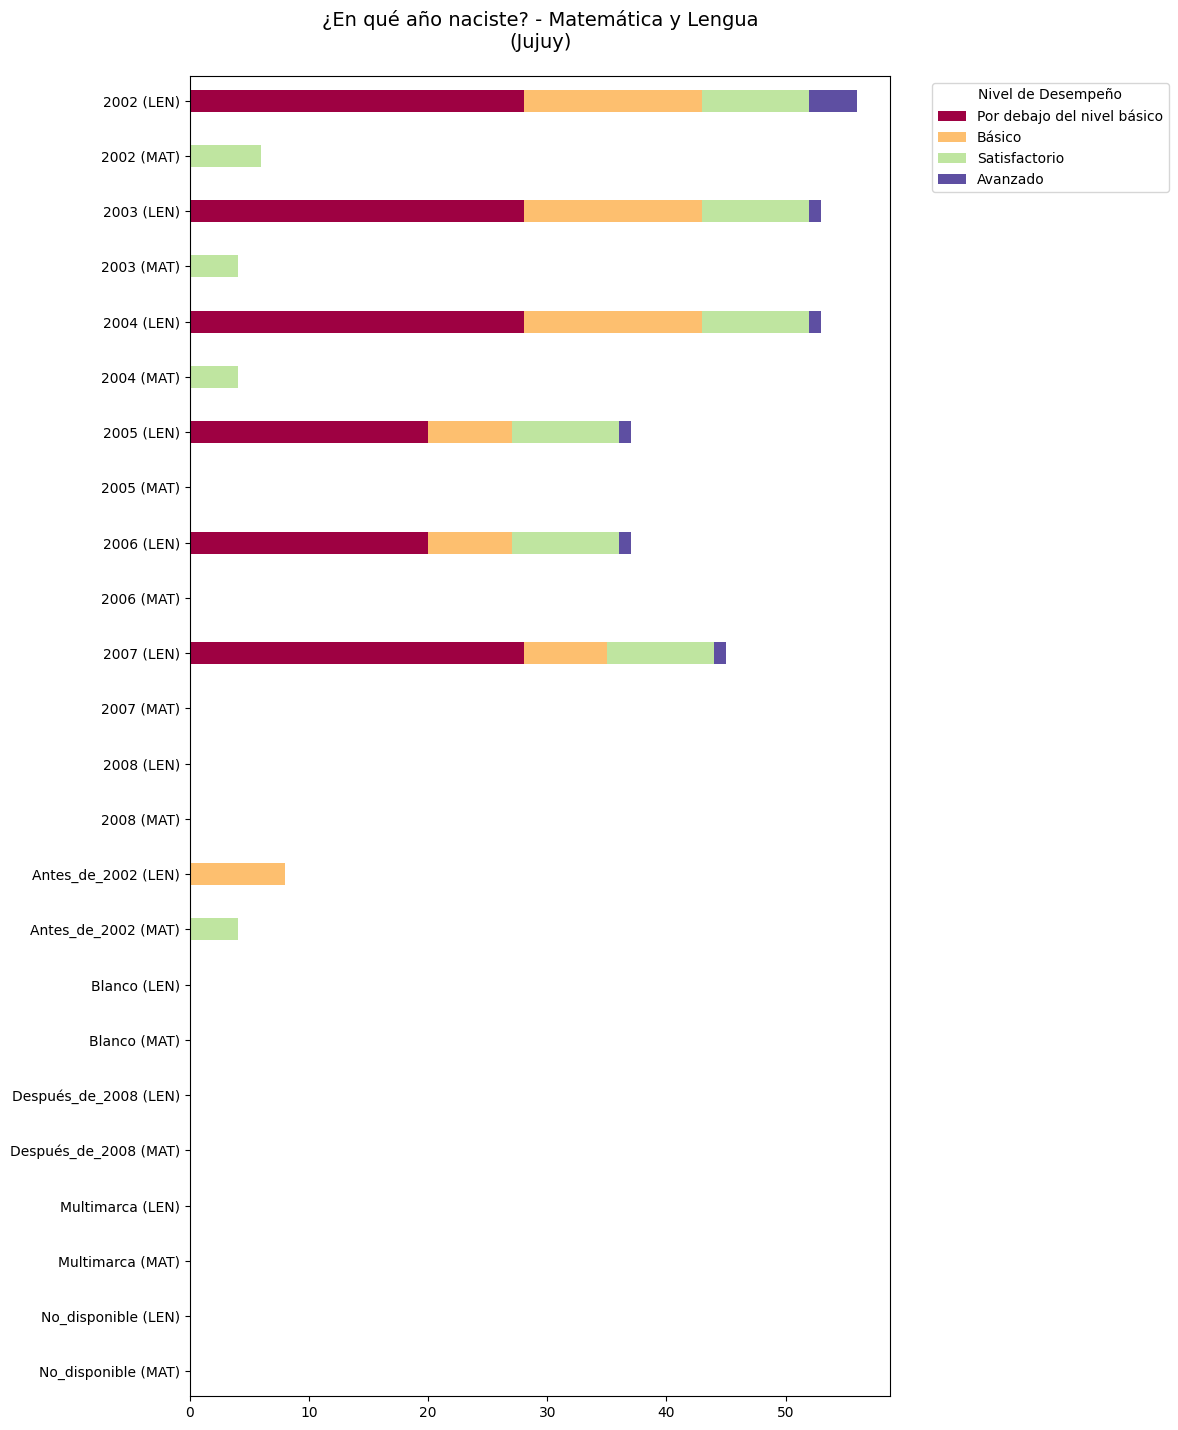

In [55]:
# --- PRUEBA SOLO CON TÍTULO ---
import matplotlib.pyplot as plt

# Agregá esta línea antes de llamar a tu función
%matplotlib inline 
# O si estás en un script .py común:
# plt.switch_backend('TkAgg') 

graficar_desempeño_flexible(df_nacional, "¿En qué año naciste?",jurisdiccion_filtro="Jujuy")


In [56]:
# Obtener la lista de provincias únicas
provincias_unicas = sorted(df_nacional['jurisdiccion'].unique().tolist())

# Crear el diccionario para el widget (Label: Value)
# Esto sirve para que en el desplegable se vea el nombre lindo
diccionario_provincias = {prov: prov for prov in provincias_unicas}

# Si querés agregar una opción para "Toda la Argentina" al principio:
opciones_provincias = ["Todas"] + provincias_unicas

In [57]:
opciones_provincias

['Todas',
 'Buenos Aires',
 'Catamarca',
 'Chaco',
 'Chubut',
 'Ciudad Autónoma de Buenos Aires',
 'Corrientes',
 'Córdoba',
 'Entre Ríos',
 'Formosa',
 'Jujuy',
 'La Pampa',
 'La Rioja',
 'Mendoza',
 'Misiones',
 'Neuquén',
 'Río Negro',
 'Salta',
 'San Juan',
 'San Luis',
 'Santa Cruz',
 'Santa Fe',
 'Santiago del Estero',
 'Tierra del Fuego, Antártida e Islas del Atlántico Sur',
 'Tucumán']